# Metrics — Complete Reference (Classification + Regression)

*Part of the ML Course Reference Series.*

## Q18: What is a Confusion Matrix?

A confusion matrix shows the **counts** of correct and incorrect predictions broken down by class:

```
                 Predicted
              Neg    Pos
Actual  Neg  [ TN    FP ]
        Pos  [ FN    TP ]
```

- **TP** True Positive: correctly predicted positive
- **TN** True Negative: correctly predicted negative
- **FP** False Positive (Type I error): predicted positive, actually negative
- **FN** False Negative (Type II error): predicted negative, actually positive

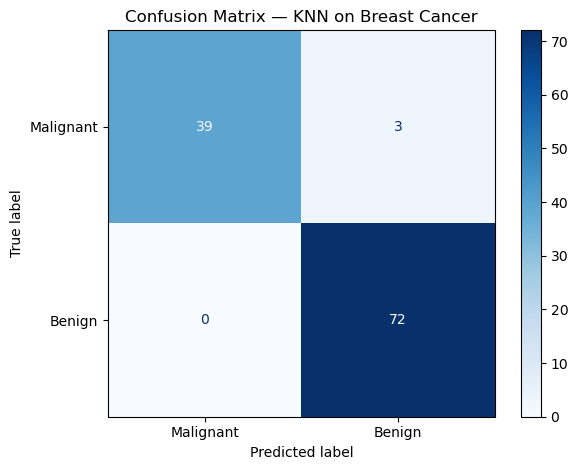

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

pipe = Pipeline([('scl', StandardScaler()),
                 ('knn', KNeighborsClassifier(n_neighbors=7))])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — KNN on Breast Cancer')
plt.tight_layout()
plt.show()

## Q19: What is Accuracy, Precision, Recall, and F1-score?

| Metric | Formula | Answers |
|---|---|---|
| **Accuracy** | (TP+TN) / all | What fraction is correct overall? |
| **Precision** | TP / (TP+FP) | Of everything I said was positive, how many actually were? |
| **Recall** | TP / (TP+FN) | Of all actual positives, how many did I catch? |
| **F1** | 2 × P×R / (P+R) | Harmonic mean — balance between precision and recall |

**When accuracy is misleading:** If 95% of emails are not spam, a model that always predicts "not spam" gets 95% accuracy but never catches spam. Precision/recall tell the real story.

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'F1 score:  {f1_score(y_test, y_pred):.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Accuracy:  0.974
Precision: 0.960


Recall:    1.000
F1 score:  0.980

              precision    recall  f1-score   support

   Malignant       1.00      0.93      0.96        42
      Benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## Q20: What is ROC-AUC and how do you interpret it?

The **ROC curve** plots True Positive Rate vs False Positive Rate at every possible classification threshold (0 → 1).

**AUC (Area Under Curve):**
- 1.0 = perfect classifier
- 0.5 = random guessing (diagonal line)
- < 0.5 = worse than random

AUC is **threshold-independent** — it tells you how well the model ranks positives above negatives, regardless of where you set the cutoff. Useful when class imbalance makes accuracy misleading.

ROC-AUC: 0.988


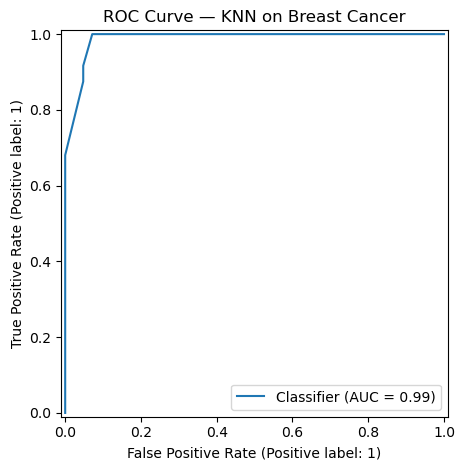

In [26]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Need predict_proba for ROC
pipe_proba = Pipeline([('scl', StandardScaler()),
                       ('knn', KNeighborsClassifier(n_neighbors=7))])
pipe_proba.fit(X_train, y_train)
y_proba = pipe_proba.predict_proba(X_test)[:, 1]

print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve — KNN on Breast Cancer')
plt.tight_layout()
plt.show()

## Q20b: When should you use which classification metric — and how to interpret?

| Metric | Use when | Watch out for |
|---|---|---|
| **Accuracy** | Classes balanced | Misleading on imbalanced data |
| **Precision** | FP is costly (spam filter, alert fatigue) | High-recall model flags everything |
| **Recall** | FN is costly (cancer detection, fraud) | High-precision model misses real cases |
| **F1** | Need balance between P and R | Hides *which* type of error is worse |
| **ROC-AUC** | Threshold-independent model comparison | Doesn't pick an operating point |

**How to read values:**
- Accuracy `0.95` on a 95/5 dataset: always predicting the majority also gets 0.95. Useless.
- Precision `0.80`: 80% of your predicted positives are truly positive.
- Recall `0.60`: you catch 60% of all real positives — miss 40%.
- F1 `0.70`: harmonic mean of P and R — a single balanced score.
- AUC `0.97`: the model ranks a random positive above a random negative 97% of the time.

**Rule of thumb:** medicine → maximise recall (don't miss). Spam filter → maximise precision (don't bin real mail).

Balanced vs imbalanced — why accuracy lies:

  Balanced (50/50)
    Naive baseline accuracy: 0.500
    Model accuracy:          0.885
    Model precision:         0.889
    Model recall:            0.880
    Model F1:                0.884


    Model ROC-AUC:           0.934

  Imbalanced (95/5)
    Naive baseline accuracy: 0.945
    Model accuracy:          0.945
    Model precision:         0.500
    Model recall:            0.182
    Model F1:                0.267
    Model ROC-AUC:           0.886


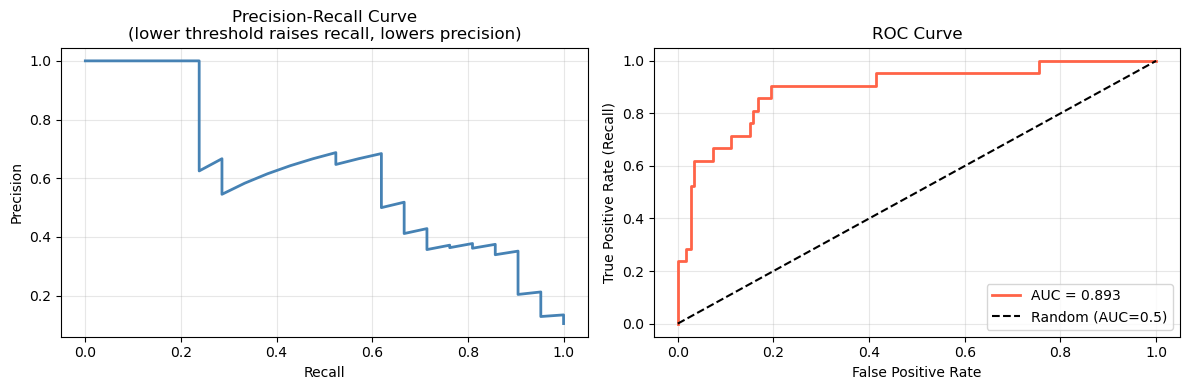

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score,
                              precision_recall_curve, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print('Balanced vs imbalanced — why accuracy lies:')
for ratio, label in [((0.5, 0.5), 'Balanced (50/50)'),
                      ((0.95, 0.05), 'Imbalanced (95/5)')]:
    X, y = make_classification(n_samples=1000, weights=list(ratio), random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                               stratify=y, random_state=42)
    pipe = Pipeline([('scl', StandardScaler()),
                     ('lr', LogisticRegression(max_iter=500))])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]
    naive = np.zeros_like(y_te)  # always predict majority
    print(f'\n  {label}')
    print(f'    Naive baseline accuracy: {accuracy_score(y_te, naive):.3f}')
    print(f'    Model accuracy:          {accuracy_score(y_te, y_pred):.3f}')
    print(f'    Model precision:         {precision_score(y_te, y_pred, zero_division=0):.3f}')
    print(f'    Model recall:            {recall_score(y_te, y_pred, zero_division=0):.3f}')
    print(f'    Model F1:                {f1_score(y_te, y_pred, zero_division=0):.3f}')
    print(f'    Model ROC-AUC:           {roc_auc_score(y_te, y_proba):.3f}')

# Precision-Recall trade-off at different thresholds
X, y = make_classification(n_samples=1000, weights=[0.9, 0.1], random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
pipe = Pipeline([('scl', StandardScaler()), ('lr', LogisticRegression(max_iter=500))])
pipe.fit(X_tr, y_tr)
proba = pipe.predict_proba(X_te)[:, 1]
prec, rec, _ = precision_recall_curve(y_te, proba)
fpr, tpr, _  = roc_curve(y_te, proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rec, prec, color='steelblue', linewidth=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve\n(lower threshold raises recall, lowers precision)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(fpr, tpr, color='tomato', linewidth=2,
             label=f'AUC = {roc_auc_score(y_te, proba):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 6. Model Evaluation — Regression

## Q21: What is MAE, MSE, and RMSE?

| Metric | Formula | Properties |
|---|---|---|
| **MAE** | mean(\|y - ŷ\|) | Same units as target; robust to outliers |
| **MSE** | mean((y - ŷ)²) | Penalises large errors heavily; not in original units |
| **RMSE** | √MSE | Same units as target; also penalises large errors |

Choose **MAE** when outliers shouldn't be penalised heavily (e.g. house prices). Choose **RMSE** when large errors are especially costly.

MAE:  44.05
MSE:  2952.01
RMSE: 54.33
R²:   0.443


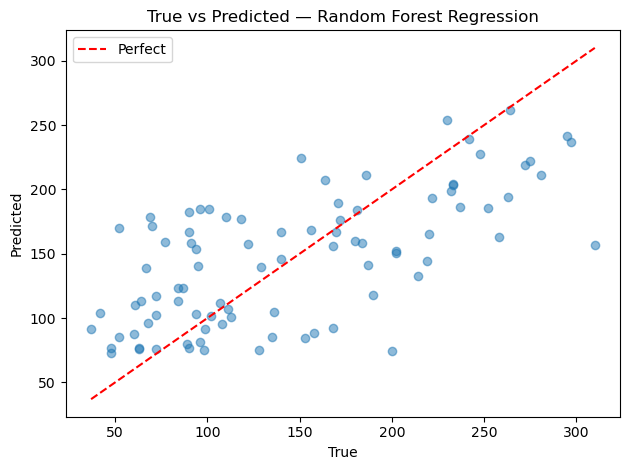

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

X_tr, X_te, y_tr, y_te = train_test_split(X_diab, y_diab, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)
y_hat = rf.predict(X_te)

mae  = mean_absolute_error(y_te, y_hat)
mse  = mean_squared_error(y_te, y_hat)
rmse = np.sqrt(mse)
r2   = r2_score(y_te, y_hat)

print(f'MAE:  {mae:.2f}')
print(f'MSE:  {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²:   {r2:.3f}')

plt.scatter(y_te, y_hat, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', label='Perfect')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('True vs Predicted — Random Forest Regression')
plt.legend()
plt.tight_layout()
plt.show()

## Q22: What is R² (coefficient of determination)?

R² measures what proportion of variance in the target is explained by the model:

```
R² = 1 - (SS_res / SS_tot)
   = 1 - Σ(y-ŷ)² / Σ(y-mean(y))²
```

- R² = 1.0 → perfect predictions
- R² = 0.0 → model does no better than predicting the mean
- R² < 0  → model is worse than predicting the mean

Unlike RMSE, R² is **scale-independent**, making it easy to compare across datasets.

In [29]:
y_true = np.array([3, -0.5, 2, 7])
y_pred_good  = np.array([2.5,  0.0, 2, 8])
y_pred_mean  = np.full_like(y_true, y_true.mean(), dtype=float)  # always predict mean
y_pred_bad   = np.array([10,  10,  10, 10])  # terrible model

for label, yp in [('Good model', y_pred_good),
                   ('Mean baseline', y_pred_mean),
                   ('Bad model', y_pred_bad)]:
    print(f'{label:15s}  R² = {r2_score(y_true, yp):.3f}')

Good model       R² = 0.949
Mean baseline    R² = 0.000
Bad model        R² = -6.957


## Q22b: How to choose and interpret regression metrics?

| Metric | Same units? | Penalises outliers? | Use when |
|---|---|---|---|
| **MAE** | Yes | No (linear) | Outliers present; interpretable error |
| **MSE** | No (squared) | Yes (quadratic) | Rarely reported; used in loss functions |
| **RMSE** | Yes | Yes (quadratic) | Large errors especially costly |
| **R²** | No (0–1) | — | Scale-free comparison across datasets |

**How to interpret:**
- MAE = 42 on house prices (in $k) → on average predictions are off by $42k.
- RMSE = 65 >> MAE = 42 → a few predictions are wildly off (outlier residuals).
- R² = 0.85 → model explains 85% of the variance.
- R² = 0.0 → no better than predicting the mean every time.
- R² < 0 → model is *worse* than the mean baseline.

**Residual plot:** predicted vs (true − predicted). Should be a horizontal band around 0. Patterns (funnel, curve) reveal problems.

  Model                MAE     RMSE       R2  Gap(RMSE-MAE)
------------------------------------------------------------
  Good model          4.02     5.09    0.916  1.06
  Outlier model       9.03    32.18   -2.345  23.15
  Mean baseline      14.19    17.59    0.000  3.40

Large RMSE-MAE gap = a few big mistakes. Mean baseline R2 = 0 by definition.


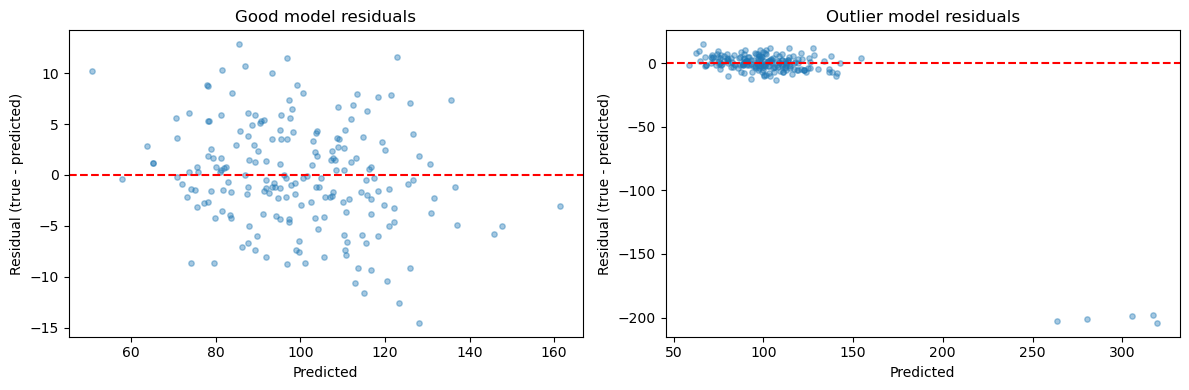

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rng = np.random.default_rng(42)
y_true = rng.normal(100, 20, 200)
y_good    = y_true + rng.normal(0, 5, 200)
y_outlier = y_true + rng.normal(0, 5, 200)
y_outlier[:5] += 200  # 5 catastrophic errors
y_mean_pred = np.full_like(y_true, y_true.mean())

print(f'  {"Model":15s}  {"MAE":>7}  {"RMSE":>7}  {"R2":>7}  Gap(RMSE-MAE)')
print('-' * 60)
for name, yp in [('Good model', y_good),
                  ('Outlier model', y_outlier),
                  ('Mean baseline', y_mean_pred)]:
    mae  = mean_absolute_error(y_true, yp)
    rmse = np.sqrt(mean_squared_error(y_true, yp))
    r2   = r2_score(y_true, yp)
    print(f'  {name:15s}  {mae:7.2f}  {rmse:7.2f}  {r2:7.3f}  {rmse-mae:.2f}')
print()
print('Large RMSE-MAE gap = a few big mistakes. Mean baseline R2 = 0 by definition.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, yp, title in [(axes[0], y_good, 'Good model residuals'),
                       (axes[1], y_outlier, 'Outlier model residuals')]:
    residuals = y_true - yp
    ax.scatter(yp, residuals, alpha=0.4, s=15)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual (true - predicted)')
    ax.set_title(title)
plt.tight_layout()
plt.show()

---
# 7. Hyperparameter Tuning & Overfitting

---
## Visual Metrics Guide — All Metrics on One Dataset

The cells below demonstrate every metric visually on the same classification
and regression problem so you can see them together and compare.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import seaborn as sns
from sklearn.datasets import make_classification, make_regression
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score,
)
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); np.random.seed(42)

# ── Classification dataset ──────────────────────────────────────────────────
Xc, yc = make_classification(n_samples=500, n_features=10,
                              weights=[0.7,0.3], random_state=42)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, random_state=42)
clf = LogisticRegression().fit(Xc_tr, yc_tr)
yc_pred  = clf.predict(Xc_te)
yc_proba = clf.predict_proba(Xc_te)[:,1]

# ── Regression dataset ───────────────────────────────────────────────────────
Xr, yr = make_regression(n_samples=500, n_features=5, noise=30, random_state=42)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.3, random_state=42)
reg = LinearRegression().fit(Xr_tr, yr_tr)
yr_pred = reg.predict(Xr_te)
residuals = yr_pred - yr_te


### Classification Metrics — All at Once

In [ ]:
# ── 1. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(yc_te, yc_pred)
tn, fp, fn, tp = cm.ravel()

fig = plt.figure(figsize=(20, 14))
g   = gs.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

ax0 = fig.add_subplot(g[0,0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax0,
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
ax0.set_title('Confusion Matrix', fontsize=11)

# ── 2. Metric bars ───────────────────────────────────────────────────────────
acc  = accuracy_score(yc_te, yc_pred)
prec = precision_score(yc_te, yc_pred)
rec  = recall_score(yc_te, yc_pred)
f1   = f1_score(yc_te, yc_pred)
ax1  = fig.add_subplot(g[0,1])
bars = ax1.bar(['Accuracy','Precision','Recall','F1'],
               [acc, prec, rec, f1],
               color=['steelblue','seagreen','coral','darkorange'], edgecolor='white')
for bar, v in zip(bars,[acc,prec,rec,f1]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{v:.3f}', ha='center', fontsize=9)
ax1.set_ylim(0,1.1); ax1.set_title('Classification Metrics', fontsize=11)
ax1.axhline(0.5, color='red', lw=1, linestyle='--', alpha=0.5, label='random baseline')
ax1.legend(fontsize=8)

# ── 3. ROC curve ─────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(yc_te, yc_proba)
roc_auc      = auc(fpr, tpr)
ax2 = fig.add_subplot(g[0,2])
ax2.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC={roc_auc:.3f})')
ax2.plot([0,1],[0,1],'k--',lw=1,label='random (AUC=0.5)')
ax2.fill_between(fpr, tpr, alpha=0.15, color='steelblue')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=11); ax2.legend(fontsize=9)

# ── 4. Precision-Recall curve ────────────────────────────────────────────────
prec_c, rec_c, _ = precision_recall_curve(yc_te, yc_proba)
ax3 = fig.add_subplot(g[0,3])
ax3.plot(rec_c, prec_c, color='seagreen', lw=2)
ax3.fill_between(rec_c, prec_c, alpha=0.15, color='seagreen')
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve\n(better for imbalanced data)', fontsize=10)

# ── 5. Threshold effect ───────────────────────────────────────────────────────
thresholds = np.linspace(0.01, 0.99, 100)
metrics_t  = {'Precision':[],'Recall':[],'F1':[]}
for t in thresholds:
    yp = (yc_proba >= t).astype(int)
    if yp.sum() == 0:
        metrics_t['Precision'].append(0); metrics_t['Recall'].append(0); metrics_t['F1'].append(0)
    else:
        metrics_t['Precision'].append(precision_score(yc_te, yp, zero_division=0))
        metrics_t['Recall'].append(recall_score(yc_te, yp))
        metrics_t['F1'].append(f1_score(yc_te, yp))
ax4 = fig.add_subplot(g[1,0:2])
for name, color in [('Precision','seagreen'),('Recall','coral'),('F1','darkorange')]:
    ax4.plot(thresholds, metrics_t[name], color=color, lw=1.5, label=name)
ax4.axvline(0.5, color='black', lw=1, linestyle='--', label='default threshold 0.5')
ax4.set_xlabel('Decision threshold'); ax4.set_ylabel('Score')
ax4.set_title('How threshold affects Precision / Recall / F1\n'
              'Raising threshold: more precise but miss more positives', fontsize=10)
ax4.legend(fontsize=9)

# ── 6. Class imbalance effect ─────────────────────────────────────────────────
ax5 = fig.add_subplot(g[1,2:4])
weights = [0.5, 0.7, 0.85, 0.95]
accs, f1s = [], []
for w in weights:
    Xw, yw = make_classification(n_samples=500, weights=[w,1-w], random_state=42)
    Xwt, Xwv, ywt, ywv = train_test_split(Xw, yw, test_size=0.3, random_state=42)
    m = LogisticRegression().fit(Xwt, ywt)
    yp = m.predict(Xwv)
    accs.append(accuracy_score(ywv, yp))
    f1s.append(f1_score(ywv, yp, zero_division=0))
ax5.plot([f'{int(w*100)}% neg' for w in weights], accs, 'o-', color='steelblue',
         lw=2, markersize=7, label='Accuracy')
ax5.plot([f'{int(w*100)}% neg' for w in weights], f1s, 's-', color='coral',
         lw=2, markersize=7, label='F1')
ax5.set_title('Class imbalance: Accuracy stays high, F1 drops\n'
              '→ Use F1/Recall when classes are imbalanced!', fontsize=10)
ax5.set_ylabel('Score'); ax5.legend(fontsize=9)

plt.suptitle('Complete Classification Metrics Reference', fontsize=14, fontweight='bold', y=1.01)
plt.show()

print('=== CONFUSION MATRIX BREAKDOWN ===')
print(f'  True Positives  (TP): {tp}  — correctly predicted positive')
print(f'  True Negatives  (TN): {tn}  — correctly predicted negative')
print(f'  False Positives (FP): {fp}  — predicted positive, actually negative (Type I error)')
print(f'  False Negatives (FN): {fn}  — predicted negative, actually positive (Type II error)')
print(f'\n  Accuracy  = (TP+TN)/(all)   = {acc:.3f}  — overall correctness')
print(f'  Precision = TP/(TP+FP)       = {prec:.3f}  — of predicted positives, how many were right?')
print(f'  Recall    = TP/(TP+FN)       = {rec:.3f}  — of actual positives, how many did we catch?')
print(f'  F1        = 2*P*R/(P+R)      = {f1:.3f}  — harmonic mean of precision & recall')
print(f'  ROC-AUC                      = {roc_auc:.3f}  — probability that model ranks + above - correctly')


### Regression Metrics — All at Once

| Metric | Formula | Unit | Interpretation |
|---|---|---|---|
| **MAE** | mean(\|y_pred − y_true\|) | same as y | Average absolute error — easy to understand |
| **MSE** | mean((y_pred − y_true)²) | y² | Penalises large errors heavily; not in original units |
| **RMSE** | √MSE | same as y | Like MAE but penalises large errors more |
| **R²** | 1 − SS_res/SS_tot | dimensionless 0–1 | Fraction of variance explained; 1 = perfect |
| **MAPE** | mean(\|error\|/\|y_true\|)×100 | % | Percentage error; intuitive but undefined at y=0 |
| **Adjusted R²** | 1 − (1−R²)(n−1)/(n−p−1) | 0–1 | R² penalised for adding useless features |


In [ ]:
mae  = mean_absolute_error(yr_te, yr_pred)
mse  = mean_squared_error(yr_te, yr_pred)
rmse = np.sqrt(mse)
r2   = r2_score(yr_te, yr_pred)
n, p = len(yr_te), Xr_te.shape[1]
r2_adj = 1 - (1-r2)*(n-1)/(n-p-1)
mape = np.mean(np.abs(residuals / yr_te)) * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Actual vs Predicted
axes[0,0].scatter(yr_te, yr_pred, alpha=0.4, s=12, color='steelblue')
lims = [min(yr_te.min(), yr_pred.min()), max(yr_te.max(), yr_pred.max())]
axes[0,0].plot(lims, lims, 'r--', lw=1.5, label='perfect prediction')
axes[0,0].set_xlabel('Actual'); axes[0,0].set_ylabel('Predicted')
axes[0,0].set_title(f'Actual vs Predicted  R²={r2:.3f}', fontsize=11)
axes[0,0].legend(fontsize=9)

# Residuals vs Predicted
axes[0,1].scatter(yr_pred, residuals, alpha=0.4, s=12, color='coral')
axes[0,1].axhline(0, color='black', lw=1)
axes[0,1].axhline(2*residuals.std(),  color='orange', lw=1, linestyle='--', label='±2 std')
axes[0,1].axhline(-2*residuals.std(), color='orange', lw=1, linestyle='--')
axes[0,1].set_xlabel('Predicted'); axes[0,1].set_ylabel('Residual')
axes[0,1].set_title('Residuals vs Predicted\n(should be random, centred at 0)', fontsize=10)
axes[0,1].legend(fontsize=9)

# Residual distribution
axes[0,2].hist(residuals, bins=40, color='seagreen', edgecolor='white')
axes[0,2].axvline(0, color='red', lw=2)
axes[0,2].set_xlabel('Residual')
axes[0,2].set_title(f'Residual distribution  std={residuals.std():.2f}\n'
                    'Centred at 0 = unbiased model', fontsize=10)

# MAE vs RMSE — penalty comparison
errors_range = np.linspace(-200, 200, 400)
axes[1,0].plot(errors_range, np.abs(errors_range), color='steelblue', lw=2, label='MAE penalty  |e|')
axes[1,0].plot(errors_range, errors_range**2 / 100, color='coral', lw=2,
               label='MSE penalty  e²/100 (scaled)')
axes[1,0].set_xlabel('Prediction error'); axes[1,0].set_ylabel('Loss contribution')
axes[1,0].set_title('MAE vs MSE: MSE punishes large errors\nmuch more than MAE', fontsize=10)
axes[1,0].legend(fontsize=9); axes[1,0].set_ylim(0, 200)

# R² visual
ss_res = np.sum(residuals**2)
ss_tot = np.sum((yr_te - yr_te.mean())**2)
axes[1,1].bar(['SS_res (unexplained)','SS_tot (total)'],
              [ss_res/ss_tot, 1.0],
              color=['coral','steelblue'], edgecolor='white', alpha=0.8)
axes[1,1].axhline(1-ss_res/ss_tot, color='seagreen', lw=2, linestyle='--',
                  label=f'R² = {r2:.3f}  (explained)')
axes[1,1].set_title(f'R² = 1 − SS_res/SS_tot = {r2:.3f}\n'
                    f'Model explains {r2*100:.1f}% of variance', fontsize=10)
axes[1,1].legend(fontsize=9)

# Metric summary table
axes[1,2].axis('off')
table_data = [
    ['MAE',          f'{mae:.2f}',    'avg |error|',        'units of y'],
    ['RMSE',         f'{rmse:.2f}',   'sqrt(avg error²)',   'units of y'],
    ['R²',           f'{r2:.4f}',     'variance explained', '0-1 (higher better)'],
    ['Adj R²',       f'{r2_adj:.4f}', 'R² - feature penalty','0-1'],
    ['MAPE',         f'{mape:.1f}%',  'avg % error',        'percentage'],
]
tbl = axes[1,2].table(cellText=table_data,
                       colLabels=['Metric','Value','Meaning','Range'],
                       cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2, 1.8)
axes[1,2].set_title('Regression Metrics Summary', fontsize=11, pad=20)

plt.suptitle('Complete Regression Metrics Reference', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print('=== WHEN TO USE WHICH REGRESSION METRIC ===')
print('  MAE   — when large errors are not disproportionately bad; easy to explain')
print('  RMSE  — default for regression; penalises large errors (outlier-sensitive)')
print('  R²    — to compare models on same dataset; understand % variance explained')
print('  MAPE  — when you need %-based error (careful: bad if y can be 0)')
print('  AdjR² — when comparing models with different numbers of features')


### Decision Guide: Which metric to report?

```
Classification:
  Is the dataset balanced?
    YES → Accuracy is fine; also report F1
    NO  → Never report Accuracy alone
          Do false positives matter more? → Precision
          Do false negatives matter more? → Recall (e.g. cancer detection)
          Both equally? → F1-score
          Need a threshold-free measure? → ROC-AUC
          Highly imbalanced + class matters? → PR-AUC (Precision-Recall curve area)

Regression:
  Need dollar/unit-scale error for stakeholders? → MAE or RMSE
  Large errors especially bad (outlier-sensitive)? → RMSE
  Want % error? → MAPE
  Comparing models or need explained-variance framing? → R²
  Adding features: are they really helping? → Adjusted R²
  Reporting both? → RMSE + R² is the standard pair
```
